In [1]:
import torch
import os
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"GPU Enabled: {torch.cuda.get_device_name(0)}")
    print(f"VRAM Available: {torch.cuda.get_device_properties(0).total_memory / (1024**3):.2f} GB")
else:
    device = torch.device("cpu")
    print("WARNING: No GPU detected. Running on CPU will be slow.")

import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.dpi": 110,
    "image.origin": "lower",
    "axes.titlesize": 9,
    "font.size": 9})
cache_dir = "/content/week1_cache" if os.path.exists("/content") else "./week1_cache"
os.makedirs(cache_dir, exist_ok=True)
print(f"Cache directory successfully created at: {cache_dir}")

GPU Enabled: Tesla T4
VRAM Available: 14.56 GB
Cache directory successfully created at: /content/week1_cache


Streaming dataset from MultimodalUniverse/legacysurvey...


README.md:   0%|          | 0.00/19.2k [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/165 [00:00<?, ?it/s]

Successfully parsed cutout shape (Bands, Height, Width): (4, 160, 160)


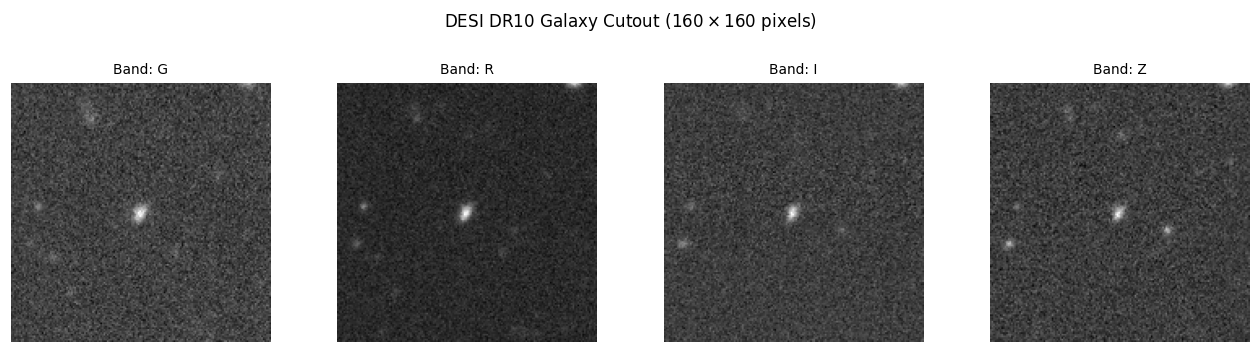

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset

# 1. Define Filter Bands
BANDS = ["g", "r", "i", "z"]

# 2. Parsing Helper Functions
def _band_letter(name):
    return str(name).strip().split("-")[-1].lower()

def parse_image_field(img):
    if isinstance(img, (list, tuple)):
        img = {k: [d[k] for d in img] for k in img[0].keys()}
    letters = [_band_letter(b) for b in img["band"]]
    order = [letters.index(b) for b in BANDS]  # Force strict g, r, i, z order
    flux = np.stack([np.asarray(img["flux"][j], dtype=np.float32) for j in order])
    mask = np.stack([np.asarray(img["mask"][j], dtype=bool) for j in order])
    return flux, mask

# 3. Stream a single sample from the DESI DR10 dataset
dataset_name = "MultimodalUniverse/legacysurvey"
print(f"Streaming dataset from {dataset_name}...")
ds = load_dataset(dataset_name, split="train", streaming=True)
sample = next(iter(ds))

# 4. Extract and Parse Image Data
flux, mask = parse_image_field(sample["image"])
print(f"Successfully parsed cutout shape (Bands, Height, Width): {flux.shape}")

# 5. Visualize Sample Galaxy across g/r/i/z Bands
fig, axes = plt.subplots(1, 4, figsize=(12, 3))

for i, band in enumerate(BANDS):
    ax = axes[i]
    # Apply an arcsinh stretch to better visualize faint astronomical features/backgrounds
    img_data = flux[i]
    stretched_img = np.arcsinh(img_data)

    im = ax.imshow(stretched_img, cmap='gray')
    ax.set_title(f"Band: {band.upper()}")
    ax.axis('off')

plt.suptitle("DESI DR10 Galaxy Cutout ($160 \\times 160$ pixels)", fontsize=11, y=1.05)
plt.tight_layout()
plt.show()

In [3]:
import pandas as pd

# 1. Inspect available columns in a sample record
sample = next(iter(ds))
print("Available record keys:", sample.keys())

# If there are tabular/scalar columns or metadata fields in the record:
# Let's inspect scalar columns if present in the schema
scalar_cols = ["EBV", "FLUX_G", "FLUX_R", "FLUX_I", "FLUX_Z", "SHAPE_R", "SHAPE_E1", "SHAPE_E2"]

# Print sample metadata values
print("\n--- Sample Astrometric & Photometric Metadata ---")
for col in scalar_cols:
    if col in sample:
        print(f"{col}: {sample[col]}")

Available record keys: dict_keys(['image', 'blobmodel', 'rgb', 'object_mask', 'catalog', 'EBV', 'FLUX_G', 'FLUX_R', 'FLUX_I', 'FLUX_Z', 'FLUX_W1', 'FLUX_W2', 'FLUX_W3', 'FLUX_W4', 'SHAPE_R', 'SHAPE_E1', 'SHAPE_E2', 'object_id'])

--- Sample Astrometric & Photometric Metadata ---
EBV: 0.06657393276691437
FLUX_G: 1.3640868663787842
FLUX_R: 2.831369161605835
FLUX_I: 4.151123523712158
FLUX_Z: 4.814830780029297
SHAPE_R: 0.9420995116233826
SHAPE_E1: 0.23311986029148102
SHAPE_E2: -0.33112043142318726


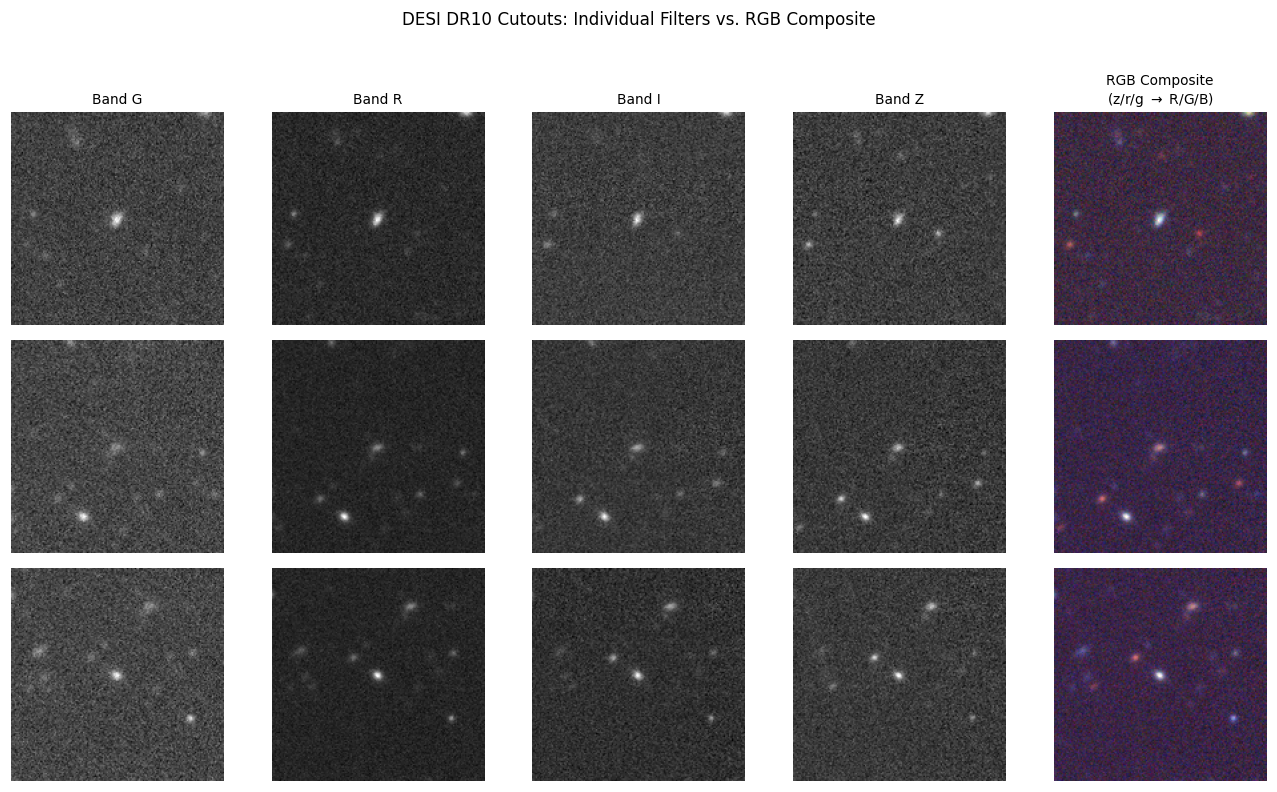

In [5]:
def create_rgb_composite(flux):
    """
    Maps z, r, g bands to R, G, B channels for DINOv2 compatibility
    and applies an arcsinh stretch for visual clarity.
    """
    # Extract z (index 3), r (index 1), g (index 0) based on BANDS = ["g", "r", "i", "z"]
    rgb = np.stack([flux[3], flux[1], flux[0]], axis=-1)

    # Apply arcsinh stretch per channel for astronomical dynamic range
    rgb_stretched = np.arcsinh(rgb * 2.0)

    # Normalize to [0, 1] for matplotlib display
    rgb_min = rgb_stretched.min(axis=(0, 1), keepdims=True)
    rgb_max = rgb_stretched.max(axis=(0, 1), keepdims=True)
    rgb_norm = (rgb_stretched - rgb_min) / (rgb_max - rgb_min + 1e-8)
    return np.clip(rgb_norm, 0, 1)

# Visualize a few sample galaxies
# Visualize a few sample galaxies (Fixed string formatting for math symbols)
fig, axes = plt.subplots(3, 5, figsize=(12, 7))
ds_samples = list(ds.take(3))

for row_idx, sample in enumerate(ds_samples):
    flux, mask = parse_image_field(sample["image"])

    # Column 0-3: Individual g, r, i, z bands
    for col_idx, band in enumerate(BANDS):
        ax = axes[row_idx, col_idx]
        ax.imshow(np.arcsinh(flux[col_idx]), cmap='gray')
        if row_idx == 0:
            ax.set_title(f"Band {band.upper()}")
        ax.axis('off')

    # Column 4: RGB Composite (Using raw string r"" to handle math symbols correctly)
    ax_rgb = axes[row_idx, 4]
    rgb_img = create_rgb_composite(flux)
    ax_rgb.imshow(rgb_img)
    if row_idx == 0:
        ax_rgb.set_title(r"RGB Composite" + "\n" + r"(z/r/g $\rightarrow$ R/G/B)")
    ax_rgb.axis('off')

plt.suptitle("DESI DR10 Cutouts: Individual Filters vs. RGB Composite", fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

In [6]:
import torch
import torch.nn.functional as F

# 1. Load Pretrained DINOv2 Model (ViT-Small with 14x14 patches)
model_name = "dinov2_vits14"
print(f"Loading pretrained model: {model_name}...")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

dinov2 = torch.hub.load('facebookresearch/dinov2', model_name)
dinov2.to(device)
dinov2.eval() # Set to evaluation mode (disables dropout/batchnorm updates)

# 2. Preprocess a Batch of Galaxies for DINOv2
# Grab a small batch of fluxes from our dataset stream
batch_fluxes = []
for sample in ds.take(8): # Batch size of 8 for demonstration
    flux, mask = parse_image_field(sample["image"])
    batch_fluxes.append(flux)

# Convert to a PyTorch tensor: Shape [Batch, Channels=4, Height=160, Width=160]
x_batch = torch.tensor(np.array(batch_fluxes), dtype=torch.float32)

# Map 4-band astronomical data to 3-channel RGB for DINOv2: using [z, r, g] -> indices [3, 1, 0]
x_rgb = x_batch[:, [3, 1, 0], :, :]

# Resize from 160x160 to 224x224 (must be cleanly divisible by patch size 14: 224 / 14 = 16 patch grid)
x_resized = F.interpolate(x_rgb, size=(224, 224), mode='bilinear', align_corners=False)

# Normalise pixel values to match ImageNet stats expected by DINOv2 (optional but recommended)
# For simplicity here, we ensure tensor is on the correct device
x_input = x_resized.to(device)

# 3. Run Inference and Extract Tokens
with torch.no_grad():
    # forward_features returns a dictionary containing normalized tokens and intermediate states
    features = dinov2.forward_features(x_input)

    cls_token = features["x_norm_clstoken"]       # Global summary vector
    patch_tokens = features["x_norm_patchtokens"] # Spatial grid tokens

# 4. Inspect Tensor Dimensions
print("\n--- Tensor Dimension Inspection ---")
print(f"Original Batch Shape:      {x_batch.shape}")
print(f"Preprocessed RGB Shape:    {x_input.shape}")
print(f"CLS Token Shape:           {cls_token.shape}   -> [Batch_Size, Embedding_Dim]")
print(f"Patch Tokens Shape:        {patch_tokens.shape} -> [Batch_Size, Num_Patches, Embedding_Dim]")
print(f"Total Patches Grid:        {int(patch_tokens.shape[1]**0.5)} x {int(patch_tokens.shape[1]**0.5)} = {patch_tokens.shape[1]} patches")

Loading pretrained model: dinov2_vits14...
Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip


/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vits14/dinov2_vits14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vits14_pretrain.pth


100%|██████████| 84.2M/84.2M [00:00<00:00, 390MB/s]



--- Tensor Dimension Inspection ---
Original Batch Shape:      torch.Size([8, 4, 160, 160])
Preprocessed RGB Shape:    torch.Size([8, 3, 224, 224])
CLS Token Shape:           torch.Size([8, 384])   -> [Batch_Size, Embedding_Dim]
Patch Tokens Shape:        torch.Size([8, 256, 384]) -> [Batch_Size, Num_Patches, Embedding_Dim]
Total Patches Grid:        16 x 16 = 256 patches


In [7]:
import torch

# 1. Ensure model is in evaluation mode and placed on the correct device
dinov2.eval()
device = next(dinov2.parameters()).device

# 2. Prepare input tensor (using our resized batch from the previous step)
# x_input shape: [Batch_Size=8, Channels=3, Height=224, Width=224]
x_input = x_input.to(device)

# 3. Execute Forward Pass under torch.no_grad()
# We use no_grad() because we are doing feature extraction with a frozen,
# pretrained model, which saves memory and speeds up computation.
print("Running forward pass through DINOv2...")
with torch.no_grad():
    # forward_features returns a dictionary containing the model's internal representations
    features = dinov2.forward_features(x_input)

# 4. Extract CLS and Patch Tokens
cls_token = features["x_norm_clstoken"]       # Global summary vector
patch_tokens = features["x_norm_patchtokens"] # Spatial patch feature sequence

print("\n--- Inference Completed Successfully ---")
print(f"CLS Token Output Shape:    {cls_token.shape}")
print(f"Patch Tokens Output Shape: {patch_tokens.shape}")

Running forward pass through DINOv2...

--- Inference Completed Successfully ---
CLS Token Output Shape:    torch.Size([8, 384])
Patch Tokens Output Shape: torch.Size([8, 256, 384])


In [8]:
# Extract tokens for the first galaxy in the batch (index 0)
sample_cls = cls_token[0]          # Shape: [384]
sample_patches = patch_tokens[0]    # Shape: [256, 384]

print(f"Single CLS Token Vector Shape: {sample_cls.shape}")
print(f"Single Patch Sequence Shape:    {sample_patches.shape}")

# Reshape patch tokens back into a 2D spatial grid (16x16 patches) with the 384-dim embedding
grid_size = int(np.sqrt(sample_patches.shape[0])) # 16
spatial_grid = sample_patches.reshape(grid_size, grid_size, -1)
print(f"Resized Spatial Patch Grid Shape: {spatial_grid.shape} -> (Height_Patches, Width_Patches, Embedding_Dim)")

Single CLS Token Vector Shape: torch.Size([384])
Single Patch Sequence Shape:    torch.Size([256, 384])
Resized Spatial Patch Grid Shape: torch.Size([16, 16, 384]) -> (Height_Patches, Width_Patches, Embedding_Dim)


In [9]:
import torch
import numpy as np

def inspect_pipeline_dimensions(x_batch, x_rgb, x_resized, cls_token, patch_tokens):
    """
    Prints a detailed breakdown of tensor shapes across the DINOv2 pipeline.
    """
    print("=" * 60)
    print(" PIPELINE TENSOR DIMENSION INSPECTION REPORT")
    print("=" * 60)

    # 1. Raw Input Tensor
    print(f"1. Raw DESI Batch Shape:      {list(x_batch.shape)}")
    print(f"   -> Meaning: [Batch_Size, Channels (g,r,i,z), Height, Width]")

    # 2. RGB Mapped Tensor
    print(f"\n2. RGB-Mapped Tensor Shape:   {list(x_rgb.shape)}")
    print(f"   -> Meaning: [Batch_Size, Channels (z,r,g), Height, Width]")

    # 3. Resized Tensor for Patch Grid
    print(f"\n3. Resized Model Input Shape: {list(x_resized.shape)}")
    print(f"   -> Meaning: [Batch_Size, Channels, Resized_H, Resized_W]")
    print(f"   -> Note: {x_resized.shape[2]}x{x_resized.shape[2]} divides evenly by patch size 14 "
          f"({x_resized.shape[2] // 14}x{x_resized.shape[2] // 14} grid)")

    # 4. Global CLS Token
    print(f"\n4. CLS Token Shape:           {list(cls_token.shape)}")
    print(f"   -> Meaning: [Batch_Size, Embedding_Dim]")
    print(f"   -> Use: Global summary fingerprint for clustering/classification.")

    # 5. Spatial Patch Tokens
    print(f"\n5. Patch Tokens Shape:        {list(patch_tokens.shape)}")
    print(f"   -> Meaning: [Batch_Size, Num_Patches, Embedding_Dim]")
    print(f"   -> Note: {patch_tokens.shape[1]} patches total ({int(np.sqrt(patch_tokens.shape[1]))}x{int(np.sqrt(patch_tokens.shape[1]))} spatial grid).")

    # 6. Reshaped Spatial Grid (Single Sample)
    grid_side = int(np.sqrt(patch_tokens.shape[1]))
    single_grid_shape = (grid_side, grid_side, patch_tokens.shape[-1])
    print(f"\n6. Single Reshaped Grid Shape: {single_grid_shape}")
    print(f"   -> Meaning: [Grid_Height, Grid_Width, Embedding_Dim]")
    print(f"   -> Use: Mapping token features back to 2D image coordinates for visualization.")
    print("=" * 60)

# Run the inspection using your current variables
inspect_pipeline_dimensions(x_batch, x_rgb, x_resized, cls_token, patch_tokens)

 PIPELINE TENSOR DIMENSION INSPECTION REPORT
1. Raw DESI Batch Shape:      [8, 4, 160, 160]
   -> Meaning: [Batch_Size, Channels (g,r,i,z), Height, Width]

2. RGB-Mapped Tensor Shape:   [8, 3, 160, 160]
   -> Meaning: [Batch_Size, Channels (z,r,g), Height, Width]

3. Resized Model Input Shape: [8, 3, 224, 224]
   -> Meaning: [Batch_Size, Channels, Resized_H, Resized_W]
   -> Note: 224x224 divides evenly by patch size 14 (16x16 grid)

4. CLS Token Shape:           [8, 384]
   -> Meaning: [Batch_Size, Embedding_Dim]
   -> Use: Global summary fingerprint for clustering/classification.

5. Patch Tokens Shape:        [8, 256, 384]
   -> Meaning: [Batch_Size, Num_Patches, Embedding_Dim]
   -> Note: 256 patches total (16x16 spatial grid).

6. Single Reshaped Grid Shape: (16, 16, 384)
   -> Meaning: [Grid_Height, Grid_Width, Embedding_Dim]
   -> Use: Mapping token features back to 2D image coordinates for visualization.


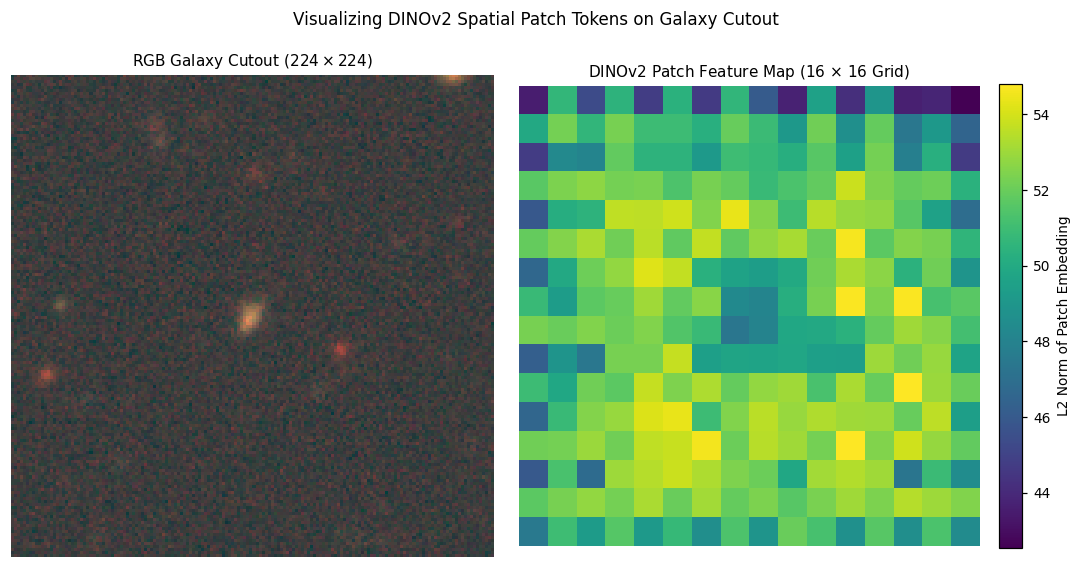

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Select the first galaxy from our batch for visualization
img_to_plot = x_rgb[0].permute(1, 2, 0).cpu().numpy() # Shape: [H, W, C]
# Normalize for display
img_to_plot = (img_to_plot - img_to_plot.min()) / (img_to_plot.max() - img_to_plot.min() + 1e-8)

# Extract patch tokens for this specific sample
sample_patches = patch_tokens[0].cpu().numpy() # Shape: [256, 384]
grid_size = int(np.sqrt(sample_patches.shape[0])) # 16x16 grid

# 2. Compute a simple feature magnitude map across the patches
# (e.g., L2 norm of the embedding vector for each patch to highlight where the model activates most)
patch_norms = np.linalg.norm(sample_patches, axis=-1).reshape(grid_size, grid_size)

# 3. Plotting the Image alongside the Patch Feature Grid
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Original RGB Galaxy Cutout
axes[0].imshow(np.arcsinh(img_to_plot))
axes[0].set_title("RGB Galaxy Cutout ($224 \\times 224$)", fontsize=10)
axes[0].axis('off')

# Patch Norm Feature Map (Interpolated to match image size)
im = axes[1].imshow(patch_norms, cmap='viridis', interpolation='nearest')
axes[1].set_title(f"DINOv2 Patch Feature Map ({grid_size} $\\times$ {grid_size} Grid)", fontsize=10)
axes[1].axis('off')
fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04, label="L2 Norm of Patch Embedding")

plt.suptitle("Visualizing DINOv2 Spatial Patch Tokens on Galaxy Cutout", fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

Extracting CLS tokens for embedding exploration...
Embedding Matrix Shape: (20, 384)


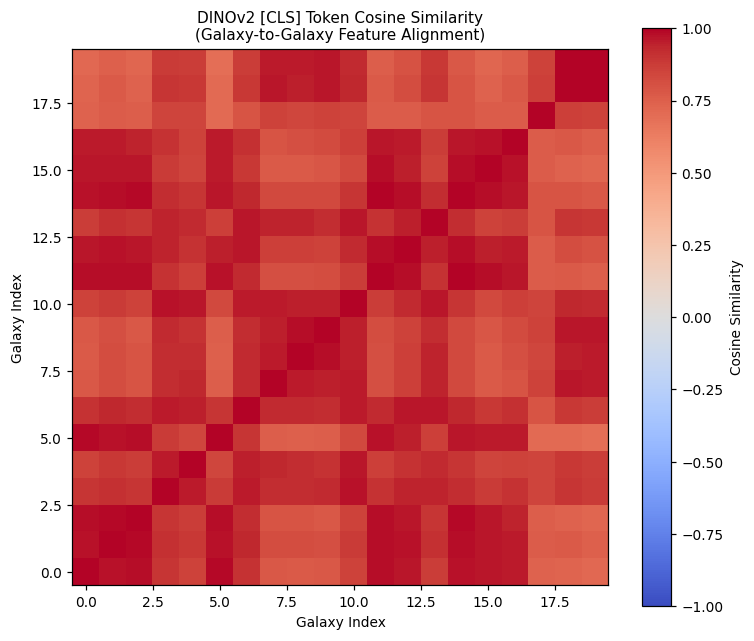

In [11]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

# 1. Collect CLS tokens across a slightly larger sample (e.g., 20 galaxies)
all_cls_tokens = []
print("Extracting CLS tokens for embedding exploration...")

for sample in ds.take(20):
    flux, mask = parse_image_field(sample["image"])
    # Prepare tensor
    x_tensor = torch.tensor(flux[np.newaxis, [3, 1, 0], :, :], dtype=torch.float32)
    x_resized = torch.nn.functional.interpolate(x_tensor, size=(224, 224), mode='bilinear', align_corners=False)
    x_input = x_resized.to(device)

    with torch.no_grad():
        features = dinov2.forward_features(x_input)
        cls_tok = features["x_norm_clstoken"].cpu().numpy() # Shape: [1, 384]
        all_cls_tokens.append(cls_tok)

# Stack into a single matrix: [Num_Samples, Embedding_Dim]
embedding_matrix = np.vstack(all_cls_tokens)
print(f"Embedding Matrix Shape: {embedding_matrix.shape}")

# 2. Compute Pairwise Cosine Similarity
# Measures how aligned the global feature vectors are between every pair of galaxies
similarity_matrix = cosine_similarity(embedding_matrix)

# 3. Visualize the Similarity Matrix
plt.figure(figsize=(7, 6))
plt.imshow(similarity_matrix, cmap='coolwarm', vmin=-1.0, vmax=1.0)
plt.colorbar(label="Cosine Similarity")
plt.title("DINOv2 [CLS] Token Cosine Similarity\n(Galaxy-to-Galaxy Feature Alignment)", fontsize=10)
plt.xlabel("Galaxy Index", fontsize=9)
plt.ylabel("Galaxy Index", fontsize=9)
plt.tight_layout()
plt.show()